<a href="https://colab.research.google.com/github/braltoids0089/FINANCE-QUANT/blob/main/NB1_THEMATIC_AWARE_EQUITY_ALPHA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thematic-Aware Equity Alpha
## Integrating Published Macro-Research Signals into AI-Driven Equity Research Pipelines

**Notebook 1 of 2** · Independent research artifact · Executable on Google Colab or Kaggle

---

### Abstract

This notebook demonstrates an end-to-end, auditable AI pipeline for equity research on US large-cap equities. We construct an Alpha158-inspired factor set from daily market data, train two cross-sectional return-prediction models (LightGBM and an LSTM), evaluate them under a walk-forward protocol using information coefficient (IC), rank IC, turnover-adjusted Sharpe ratio, and maximum drawdown, and then apply a **thematic overlay** — sector/industry tilts derived from publicly-released macro-research surveys — as a post-prediction adjustment. The overlay is tested as an orthogonal source of return, so the quality of the ML signal can be judged independently of the macro view.

The broader intent is pedagogical and professional: to illustrate how an equity research analyst can augment (not replace) thesis generation with a reproducible ML pipeline whose every step is documented, attributable, and legible to risk and compliance reviewers.


### Disclaimer and scope

*This is an independent educational and research notebook. It is not affiliated with, endorsed by, or sponsored by HSBC Holdings plc, HSBC Global Research, or any member of the HSBC Group, nor by any of the other research providers referenced. References to publicly-released HSBC Global Research publications (e.g., Trade Pulse Survey, Emerging Markets Sentiment Survey, Sustainability Pulse Survey) are made for academic commentary purposes under **nominative fair use**. No proprietary data, non-public research, or trademarked visual elements are reproduced. All trademarks are the property of their respective owners.*

*Nothing in this notebook constitutes investment advice. All returns shown are simulated, in-sample or out-of-sample backtests on historical data, and are not indicative of future performance. Past performance does not guarantee future results.*


### Licensing of tooling used in this notebook

All libraries used in this pipeline are released under permissive open-source licenses compatible with educational and commercial use:

| Library | License | Purpose |
| --- | --- | --- |
| `numpy`, `pandas`, `scipy`, `scikit-learn` | BSD-3 | Numerical and statistical computing |
| `yfinance` | Apache-2.0 | Market-data acquisition (Yahoo Finance ToS applies) |
| `lightgbm` | MIT | Gradient-boosted trees |
| `torch` (PyTorch) | BSD-3 (modified) | Neural-network training |
| `matplotlib` | PSF-based | Plotting |

See the full `NOTICES` section at the end of this notebook.


### Table of contents

1. **Phase 0** — Environment setup and configuration
2. **Phase 1** — Universe definition and market-data acquisition
3. **Phase 2** — Feature engineering (Alpha158-inspired, ~50 features)
4. **Phase 3** — Target construction (cross-sectional forward-return rank)
5. **Phase 4** — Walk-forward split protocol
6. **Phase 5** — Model A: LightGBM baseline
7. **Phase 6** — Model B: LSTM (PyTorch)
8. **Phase 7** — Rank-blend ensemble
9. **Phase 8** — Evaluation (IC, Rank IC, Sharpe, MDD, turnover)
10. **Phase 9** — Thematic overlay from published macro-research
11. **Phase 10** — Feature importance (gain-based)
12. **Phase 11** — Caveats, limitations, and next steps
13. **Phase 12** — References and full notices


---

## Phase 0 — Environment setup and configuration

We pin major dependency versions for reproducibility. The notebook is designed to run on **Google Colab (free tier)** or **Kaggle kernels**; a GPU is helpful but not required (the LSTM falls back to CPU gracefully).


In [1]:
import sys, subprocess

PACKAGES = [
    "numpy>=2.0,<2.2", # Updated for Python 3.12 compatibility
    "pandas>=2.1,<2.3",
    "scipy>=1.13",      # Updated for numpy 2.x compatibility
    "scikit-learn>=1.4",
    "lightgbm>=4.3",
    "yfinance>=0.2.40",
    "matplotlib>=3.7",
    "tqdm>=4.66",
]

def pip_install(pkgs):
    # First, uninstall potentially problematic packages to ensure clean reinstallation
    problematic_pkgs = ["numpy", "scipy", "lightgbm"]
    for pkg in problematic_pkgs:
        try:
            print(f"Uninstalling {pkg}...")
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", pkg])
        except subprocess.CalledProcessError:
            print(f"  {pkg} not found or could not be uninstalled, continuing.")

    cmd = [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--force-reinstall"] + pkgs
    subprocess.check_call(cmd)

try:
    pip_install(PACKAGES)
    print("Dependencies installed/upgraded.")
except Exception as e:
    print(f"Install step encountered an issue (may be harmless on Colab/Kaggle): {e}")

Uninstalling numpy...
Uninstalling scipy...
Uninstalling lightgbm...
Dependencies installed/upgraded.


In [2]:
# Imports
import os
import json
import math
import warnings
import random
from pathlib import Path
from datetime import datetime, timedelta
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Added import for seaborn
from tqdm.auto import tqdm

import yfinance as yf
import lightgbm as lgb

from scipy import stats
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")
print(f"LightGBM : {lgb.__version__}")
print(f"Torch    : {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

NumPy    : 2.1.3
Pandas   : 2.2.3
LightGBM : 4.6.0
Torch    : 2.10.0+cu128 | CUDA available: True


In [3]:
# Global configuration. Adjust SEED, date windows, and universe size here.

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CACHE_DIR = Path("./cache"); CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("./outputs"); OUTPUT_DIR.mkdir(exist_ok=True)

START_DATE = "2016-01-01"
END_DATE   = "2024-12-31"

# Target variable: forward-return horizon (trading days)
FORWARD_HORIZON = 5

# Walk-forward window definition (all lengths in calendar days for simplicity)
TRAIN_DAYS = 365 * 3
VAL_DAYS   = 90
TEST_DAYS  = 90
STEP_DAYS  = 90   # rolling step forward per window

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Config: SEED={SEED}  horizon={FORWARD_HORIZON}d  device={DEVICE}")
print(f"Window: train={TRAIN_DAYS}d  val={VAL_DAYS}d  test={TEST_DAYS}d  step={STEP_DAYS}d")


Config: SEED=42  horizon=5d  device=cuda
Window: train=1095d  val=90d  test=90d  step=90d


---

## Phase 1 — Universe definition and market-data acquisition

We use a fixed universe of ~100 large-cap US equities. Keeping the universe fixed across the full period (rather than using a time-varying index constituent list) avoids survivorship-bias claims being the *source* of any alpha we observe, at the cost of mild look-ahead bias in universe construction. We document this explicitly in the caveats section.

Data is pulled from Yahoo Finance via `yfinance`. We cache the downloaded panel to disk so repeated notebook runs do not re-hit the API.


In [4]:
# Fixed universe of ~100 large-cap US equities with their GICS sector assignment.
# Sector mapping is hand-curated from public filings / GICS classifications.
# This is illustrative; a production run would pull a time-varying constituent list.

UNIVERSE_WITH_SECTOR = {
    # Information Technology
    "AAPL": "Information Technology", "MSFT": "Information Technology",
    "NVDA": "Information Technology", "AVGO": "Information Technology",
    "ORCL": "Information Technology", "CRM":  "Information Technology",
    "ADBE": "Information Technology", "CSCO": "Information Technology",
    "AMD":  "Information Technology", "INTC": "Information Technology",
    "QCOM": "Information Technology", "TXN":  "Information Technology",
    "IBM":  "Information Technology", "NOW":  "Information Technology",
    "INTU": "Information Technology", "AMAT": "Information Technology",
    "MU":   "Information Technology", "LRCX": "Information Technology",
    "KLAC": "Information Technology",

    # Communication Services
    "GOOGL": "Communication Services", "META": "Communication Services",
    "NFLX":  "Communication Services", "DIS":  "Communication Services",
    "CMCSA": "Communication Services", "T":    "Communication Services",
    "VZ":    "Communication Services",

    # Consumer Discretionary
    "AMZN": "Consumer Discretionary", "TSLA": "Consumer Discretionary",
    "HD":   "Consumer Discretionary", "MCD":  "Consumer Discretionary",
    "NKE":  "Consumer Discretionary", "LOW":  "Consumer Discretionary",
    "SBUX": "Consumer Discretionary", "BKNG": "Consumer Discretionary",
    "TJX":  "Consumer Discretionary",

    # Consumer Staples
    "PG":  "Consumer Staples", "KO":  "Consumer Staples",
    "PEP": "Consumer Staples", "WMT": "Consumer Staples",
    "COST":"Consumer Staples", "MDLZ":"Consumer Staples",
    "CL":  "Consumer Staples", "MO":  "Consumer Staples",

    # Health Care
    "UNH":  "Health Care", "JNJ":  "Health Care",
    "LLY":  "Health Care", "PFE":  "Health Care",
    "ABBV": "Health Care", "MRK":  "Health Care",
    "TMO":  "Health Care", "ABT":  "Health Care",
    "DHR":  "Health Care", "BMY":  "Health Care",
    "AMGN": "Health Care", "GILD": "Health Care",
    "CVS":  "Health Care", "MDT":  "Health Care",

    # Financials
    "JPM":  "Financials", "BAC":  "Financials",
    "WFC":  "Financials", "GS":   "Financials",
    "MS":   "Financials", "C":    "Financials",
    "BLK":  "Financials", "AXP":  "Financials",
    "SPGI": "Financials", "CB":   "Financials",
    "SCHW": "Financials",

    # Industrials
    "HON": "Industrials", "UNP": "Industrials",
    "UPS": "Industrials", "CAT": "Industrials",
    "BA":  "Industrials", "DE":  "Industrials",
    "GE":  "Industrials", "RTX": "Industrials",
    "LMT": "Industrials", "MMM": "Industrials",
    "FDX": "Industrials", "ETN": "Industrials",

    # Energy
    "XOM": "Energy", "CVX": "Energy",
    "COP": "Energy", "SLB": "Energy",
    "EOG": "Energy",

    # Utilities
    "NEE": "Utilities", "DUK": "Utilities",
    "SO":  "Utilities", "AEP": "Utilities",

    # Materials
    "LIN":  "Materials", "SHW": "Materials",
    "FCX":  "Materials", "NEM": "Materials",

    # Real Estate
    "AMT": "Real Estate", "PLD": "Real Estate",
    "EQIX":"Real Estate",
}

UNIVERSE = sorted(UNIVERSE_WITH_SECTOR.keys())
print(f"Universe size: {len(UNIVERSE)} tickers across {len(set(UNIVERSE_WITH_SECTOR.values()))} GICS sectors")

# Sector distribution summary
sec_counts = pd.Series(list(UNIVERSE_WITH_SECTOR.values())).value_counts()
print("\nSector distribution:")
print(sec_counts.to_string())


Universe size: 96 tickers across 11 GICS sectors

Sector distribution:
Information Technology    19
Health Care               14
Industrials               12
Financials                11
Consumer Discretionary     9
Consumer Staples           8
Communication Services     7
Energy                     5
Utilities                  4
Materials                  4
Real Estate                3


In [5]:
# Download daily OHLCV with retry logic and resilient caching.
# Uses pickle (dep-free) for the cache; yfinance occasionally rate-limits or
# returns intermittent errors, so we retry individual tickers.

import time, pickle

def _normalize_ticker_frame(raw_sub: pd.DataFrame, ticker: str) -> pd.DataFrame:
    sub = raw_sub.copy()
    sub["ticker"] = ticker
    sub = sub.reset_index()
    sub.columns = [str(c).lower() if not isinstance(c, tuple) else str(c[0]).lower()
                   for c in sub.columns]
    if "date" not in sub.columns and "index" in sub.columns:
        sub = sub.rename(columns={"index": "date"})
    wanted = ["date", "ticker", "open", "high", "low", "close", "volume"]
    for w in wanted:
        if w not in sub.columns:
            return pd.DataFrame()
    return sub[wanted]

def download_panel(tickers, start, end, cache_path: Path, max_retries: int = 3):
    if cache_path.exists():
        print(f"Loading cached panel from {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    print(f"Downloading {len(tickers)} tickers from Yahoo Finance ({start} -> {end}) ...")
    frames = []
    failed = list(tickers)

    for attempt in range(max_retries):
        if not failed:
            break
        print(f"  Attempt {attempt+1}/{max_retries}: fetching {len(failed)} ticker(s)...")
        try:
            raw = yf.download(
                failed, start=start, end=end,
                auto_adjust=True, progress=False, threads=True,
                group_by="ticker",
            )
        except Exception as e:
            print(f"    batch call raised: {e}")
            raw = pd.DataFrame()

        new_failed = []
        for t in failed:
            try:
                if isinstance(raw.columns, pd.MultiIndex):
                    if t not in raw.columns.get_level_values(0):
                        new_failed.append(t); continue
                    sub = raw[t]
                else:
                    sub = raw
                sub = sub.dropna(how="all")
                if sub.empty:
                    new_failed.append(t); continue
                norm = _normalize_ticker_frame(sub, t)
                if norm.empty or norm["close"].isna().all():
                    new_failed.append(t); continue
                frames.append(norm)
            except Exception:
                new_failed.append(t)
        failed = new_failed
        if failed and attempt < max_retries - 1:
            time.sleep(2)  # back off before retry

    if failed:
        print(f"  [warn] {len(failed)} ticker(s) failed after {max_retries} attempts: {failed[:10]}{'...' if len(failed)>10 else ''}")

    if not frames:
        raise RuntimeError(
            "No ticker data could be downloaded. Check network connectivity to Yahoo Finance, "
            "or reduce the universe. On Colab/Kaggle this typically works fine."
        )

    panel = pd.concat(frames, ignore_index=True).dropna(subset=["close"])
    panel["date"] = pd.to_datetime(panel["date"])
    panel = panel.sort_values(["ticker", "date"]).reset_index(drop=True)
    with open(cache_path, "wb") as f:
        pickle.dump(panel, f)
    print(f"Saved panel: {panel.shape} rows to {cache_path}")
    print(f"Successfully retrieved {panel['ticker'].nunique()} / {len(tickers)} tickers.")
    return panel

PANEL = download_panel(UNIVERSE, START_DATE, END_DATE, CACHE_DIR / "panel_ohlcv.pkl")
PANEL.head()


  Attempt 1/3: fetching 96 ticker(s)...
Saved panel: (217248, 7) rows to cache/panel_ohlcv.pkl
Successfully retrieved 96 / 96 tickers.


,date,ticker,open,high,low,close,volume
0,2016-01-04,AAPL,23.113746,23.735459,22.976339,23.730953,270597600
1,2016-01-05,AAPL,23.821052,23.843577,23.068690,23.136267,223164000
2,2016-01-06,AAPL,22.651957,23.059675,22.496530,22.683493,273829600
3,2016-01-07,AAPL,22.228475,22.555099,21.721644,21.726149,324377600
4,2016-01-08,AAPL,22.199186,22.325330,21.795973,21.841024,283192000


In [6]:
# Data quality: coverage per ticker and date range.
coverage = PANEL.groupby("ticker").agg(
    n_rows=("date", "count"),
    start=("date", "min"),
    end=("date", "max"),
)
print(f"Panel total rows: {len(PANEL):,}")
print(f"Date range:       {PANEL['date'].min().date()} -> {PANEL['date'].max().date()}")
print(f"Tickers with data: {coverage.shape[0]} / {len(UNIVERSE)}")
print(f"\nPer-ticker row-count stats:")
print(coverage['n_rows'].describe().to_string())

# Drop any ticker with <80% of max coverage (avoids late-listed names skewing features)
MAX_ROWS = coverage['n_rows'].max()
keep = coverage[coverage['n_rows'] >= 0.80 * MAX_ROWS].index.tolist()
dropped = [t for t in UNIVERSE if t not in keep]
if dropped:
    print(f"\nDropping for insufficient history: {dropped}")
    PANEL = PANEL[PANEL['ticker'].isin(keep)].reset_index(drop=True)

UNIVERSE = sorted(set(PANEL['ticker'].unique()))
print(f"Final universe: {len(UNIVERSE)} tickers")


Panel total rows: 217,248
Date range:       2016-01-04 -> 2024-12-30
Tickers with data: 96 / 96

Per-ticker row-count stats:
count      96.0
mean     2263.0
std         0.0
min      2263.0
25%      2263.0
50%      2263.0
75%      2263.0
max      2263.0
Final universe: 96 tickers


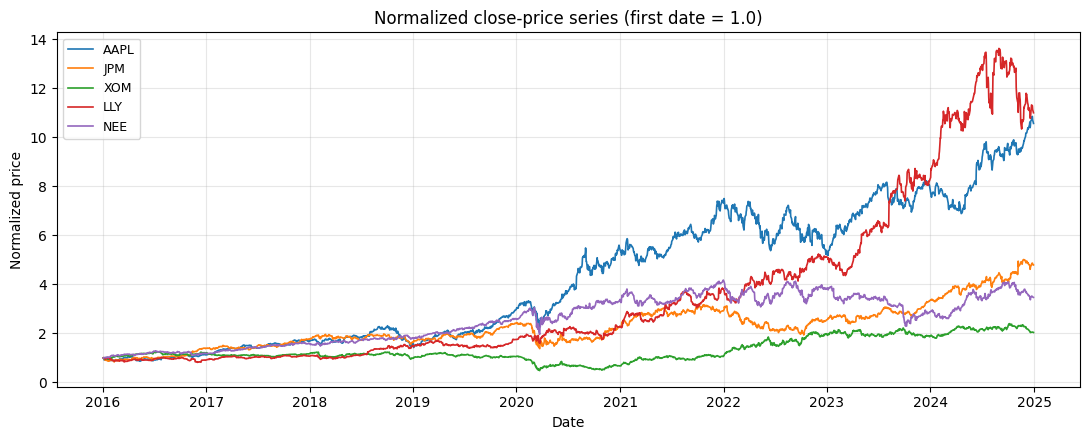

In [7]:
# Quick visual sanity check: plot a few normalized price series.
sample = ["AAPL", "JPM", "XOM", "LLY", "NEE"]
sample = [t for t in sample if t in UNIVERSE]

fig, ax = plt.subplots(figsize=(11, 4.5))
for t in sample:
    s = PANEL[PANEL['ticker'] == t].set_index("date")["close"]
    ax.plot(s.index, s / s.iloc[0], label=t, linewidth=1.2)
ax.set_title("Normalized close-price series (first date = 1.0)")
ax.set_xlabel("Date"); ax.set_ylabel("Normalized price")
ax.legend(loc="best", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---

## Phase 2 — Feature engineering

We construct an Alpha158-inspired feature set — approximately 50 features per (ticker, date) observation — spanning return dynamics, price-shape intraday patterns, volatility regimes, volume flow, and market-relative structure. Feature design follows the general philosophy of Microsoft Qlib's Alpha158 and Alpha360 handlers, reimplemented here natively so the notebook is portable and each feature's formula is transparent.

**Design principles:**
1. **No look-ahead**: every feature at time *t* uses only information available at or before *t*.
2. **Stationarity**: features are returns, ratios, z-scores, or correlations — not raw prices — so their distribution is approximately stable over time.
3. **Cross-sectional comparability**: features have similar scale across tickers, allowing cross-sectional ranking.


In [8]:
# Helper: rolling operations with safe handling of short histories.

def _rank_xs(df_col: pd.Series, group_col: pd.Series) -> pd.Series:
    '''Cross-sectional rank within each date, returned as [0, 1].'''
    return df_col.groupby(group_col).rank(pct=True)

def build_return_features(df: pd.DataFrame) -> pd.DataFrame:
    '''Return-based features, computed per ticker.'''
    g = df.groupby("ticker", group_keys=False)
    out = pd.DataFrame(index=df.index)
    close = df["close"]

    # Simple returns at multiple horizons
    for h in [1, 5, 10, 20, 60]:
        out[f"ret_{h}d"] = g["close"].pct_change(h)

    # Log returns
    logc = np.log(close)
    for h in [1, 5, 10, 20, 60]:
        out[f"logret_{h}d"] = logc.groupby(df["ticker"]).diff(h)

    # Rolling z-score of 1-day return
    r1 = out["ret_1d"]
    for w in [20, 60]:
        mu = r1.groupby(df["ticker"]).transform(lambda s: s.rolling(w).mean())
        sd = r1.groupby(df["ticker"]).transform(lambda s: s.rolling(w).std())
        out[f"ret_z_{w}"] = (r1 - mu) / (sd + 1e-9)

    # Rolling skew / kurt of returns
    for w in [20, 60]:
        out[f"ret_skew_{w}"] = r1.groupby(df["ticker"]).transform(lambda s: s.rolling(w).skew())
        out[f"ret_kurt_{w}"] = r1.groupby(df["ticker"]).transform(lambda s: s.rolling(w).kurt())

    # Return autocorrelation (lag 1)
    out["ret_ac1_20"] = r1.groupby(df["ticker"]).transform(
        lambda s: s.rolling(20).apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)
    )

    # Max / min over trailing window
    for w in [20, 60]:
        out[f"ret_max_{w}"] = r1.groupby(df["ticker"]).transform(lambda s: s.rolling(w).max())
        out[f"ret_min_{w}"] = r1.groupby(df["ticker"]).transform(lambda s: s.rolling(w).min())

    return out


In [9]:
def build_price_shape_features(df: pd.DataFrame) -> pd.DataFrame:
    '''Intraday shape features (KMID, KLEN, upper/lower shadow) + MA ratios.'''
    out = pd.DataFrame(index=df.index)
    o, h, l, c = df["open"], df["high"], df["low"], df["close"]

    # Candle-shape primitives normalized by open
    out["kmid"]  = (c - o) / (o + 1e-9)
    out["klen"]  = (h - l) / (o + 1e-9)
    out["kmid2"] = (c - o) / (h - l + 1e-9)
    out["kup"]   = (h - np.maximum(o, c)) / (o + 1e-9)
    out["klow"]  = (np.minimum(o, c) - l) / (o + 1e-9)
    out["ksft"]  = (2 * c - h - l) / (o + 1e-9)

    # Moving-average ratios
    for w in [5, 10, 20, 60]:
        ma = c.groupby(df["ticker"]).transform(lambda s: s.rolling(w).mean())
        out[f"ma_ratio_{w}"] = c / (ma + 1e-9) - 1

    # Distance from rolling max/min
    for w in [20, 60]:
        rmax = c.groupby(df["ticker"]).transform(lambda s: s.rolling(w).max())
        rmin = c.groupby(df["ticker"]).transform(lambda s: s.rolling(w).min())
        out[f"price_pos_{w}"] = (c - rmin) / (rmax - rmin + 1e-9)

    return out


In [10]:
def build_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    '''Realized and range-based volatility estimators.'''
    out = pd.DataFrame(index=df.index)
    o, h, l, c = df["open"], df["high"], df["low"], df["close"]
    logc = np.log(c)
    r1 = logc.groupby(df["ticker"]).diff(1)

    # Realized volatility at multiple windows
    for w in [5, 20, 60]:
        out[f"rvol_{w}"] = r1.groupby(df["ticker"]).transform(lambda s: s.rolling(w).std())

    # Parkinson range-based vol (log-range squared)
    log_hl = np.log(h / (l + 1e-9))
    pk = (log_hl ** 2) / (4 * math.log(2))
    for w in [10, 20]:
        out[f"park_{w}"] = pk.groupby(df["ticker"]).transform(lambda s: s.rolling(w).mean()).pow(0.5)

    # Garman-Klass estimator
    gk = 0.5 * (np.log(h / (l + 1e-9)) ** 2) - (2 * math.log(2) - 1) * (np.log(c / (o + 1e-9)) ** 2)
    for w in [10, 20]:
        out[f"gk_{w}"] = gk.groupby(df["ticker"]).transform(lambda s: s.rolling(w).mean()).clip(lower=0).pow(0.5)

    # Vol of vol
    rv20 = out["rvol_20"]
    out["vov_60"] = rv20.groupby(df["ticker"]).transform(lambda s: s.rolling(60).std())

    return out


In [11]:
def build_volume_features(df: pd.DataFrame) -> pd.DataFrame:
    '''Volume flow and price-volume interaction features.'''
    out = pd.DataFrame(index=df.index)
    v, c = df["volume"].astype(float), df["close"]
    r1 = c.groupby(df["ticker"]).pct_change(1)

    log_v = np.log1p(v)
    out["log_vol"] = log_v

    for w in [5, 20]:
        mu = log_v.groupby(df["ticker"]).transform(lambda s: s.rolling(w).mean())
        out[f"vol_ratio_{w}"] = log_v - mu  # log-space ratio = ln(v / avg)

    # Volume z-score
    sd20 = log_v.groupby(df["ticker"]).transform(lambda s: s.rolling(20).std())
    mu20 = log_v.groupby(df["ticker"]).transform(lambda s: s.rolling(20).mean())
    out["vol_z_20"] = (log_v - mu20) / (sd20 + 1e-9)

    # Price-volume correlation (rolling)
    def _corr(block, w):
        return block["a"].rolling(w).corr(block["b"])
    for w in [10, 20]:
        tmp = pd.DataFrame({"a": r1, "b": log_v, "tk": df["ticker"]})
        out[f"pv_corr_{w}"] = tmp.groupby("tk", group_keys=False).apply(
            lambda g: _corr(g, w)
        ).reset_index(level=0, drop=True)

    return out


In [12]:
def build_market_relative_features(df: pd.DataFrame, market_ticker: str = "SPY") -> pd.DataFrame:
    '''Beta and residual features against a market proxy.

    We pull SPY separately, merge on date, compute rolling beta / correlation.
    '''
    out = pd.DataFrame(index=df.index)

    # Fetch SPY if not already in panel; compute its 1d return
    spy_cache = CACHE_DIR / "spy_ohlcv.pkl"
    if spy_cache.exists():
        import pickle
        with open(spy_cache, "rb") as f:
            spy = pickle.load(f)
    else:
        import pickle
        try:
            spy_raw = yf.download(market_ticker, start=START_DATE, end=END_DATE,
                                  auto_adjust=True, progress=False)
        except Exception as e:
            print(f"  [warn] SPY download failed: {e}. Using equal-weight market proxy instead.")
            spy_raw = pd.DataFrame()
        if spy_raw.empty:
            # Fallback: synthesize a market proxy from the mean close across universe tickers
            mkt = df.groupby("date")["close"].mean().reset_index()
            mkt.columns = ["date", "spy_close"]
            spy = mkt
        else:
            if isinstance(spy_raw.columns, pd.MultiIndex):
                spy_raw.columns = [c[0] for c in spy_raw.columns]
            spy = spy_raw[["Close"]].rename(columns={"Close": "spy_close"}).reset_index()
            spy.columns = [str(c).lower() for c in spy.columns]
            if "date" not in spy.columns:
                spy = spy.rename(columns={spy.columns[0]: "date"})
        spy["date"] = pd.to_datetime(spy["date"])
        with open(spy_cache, "wb") as f:
            pickle.dump(spy, f)
    # Ensure columns are clean
    spy = spy[["date", "spy_close"]].copy()
    spy["date"] = pd.to_datetime(spy["date"])
    spy["spy_ret"] = spy["spy_close"].pct_change(1)

    merged = df[["date", "ticker"]].merge(spy[["date", "spy_ret"]], on="date", how="left")
    r1 = df["close"].groupby(df["ticker"]).pct_change(1)

    # Rolling 60-day beta and correlation
    w = 60
    tmp = pd.DataFrame({
        "r": r1.values,
        "m": merged["spy_ret"].values,
        "tk": df["ticker"].values,
    }, index=df.index)

    def _rolling_beta(block):
        cov = block["r"].rolling(w).cov(block["m"])
        var = block["m"].rolling(w).var()
        return cov / (var + 1e-9)

    def _rolling_corr(block):
        return block["r"].rolling(w).corr(block["m"])

    out[f"beta_{w}"] = tmp.groupby("tk", group_keys=False).apply(_rolling_beta).reset_index(level=0, drop=True)
    out[f"mcorr_{w}"] = tmp.groupby("tk", group_keys=False).apply(_rolling_corr).reset_index(level=0, drop=True)

    # Cross-sectional rank of 1d return (daily)
    out["ret1d_xsrank"] = r1.groupby(df["date"]).rank(pct=True)

    return out


In [13]:
# Assemble the full feature panel.

print("Building feature panel (this takes ~20-60s on Colab)...")

feat_dfs = []
feat_dfs.append(build_return_features(PANEL))
feat_dfs.append(build_price_shape_features(PANEL))
feat_dfs.append(build_volatility_features(PANEL))
feat_dfs.append(build_volume_features(PANEL))
feat_dfs.append(build_market_relative_features(PANEL))

FEATURES = pd.concat([PANEL[["date", "ticker"]]] + feat_dfs, axis=1)
FEATURE_COLS = [c for c in FEATURES.columns if c not in ("date", "ticker")]

print(f"Feature panel shape : {FEATURES.shape}")
print(f"Number of features  : {len(FEATURE_COLS)}")
print(f"First 10 features   : {FEATURE_COLS[:10]}")


Building feature panel (this takes ~20-60s on Colab)...


/tmp/ipykernel_3722/2829892531.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out[f"pv_corr_{w}"] = tmp.groupby("tk", group_keys=False).apply(
/tmp/ipykernel_3722/2829892531.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out[f"pv_corr_{w}"] = tmp.groupby("tk", group_keys=False).apply(
/tmp/ipykernel_3722/175653476.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns

Feature panel shape : (217248, 52)
Number of features  : 50
First 10 features   : ['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'logret_1d', 'logret_5d', 'logret_10d', 'logret_20d', 'logret_60d']


In [14]:
# Feature sanity: distribution summary and missing-rate by feature.
summary = FEATURES[FEATURE_COLS].describe(percentiles=[0.01, 0.5, 0.99]).T
summary["missing_rate"] = FEATURES[FEATURE_COLS].isna().mean()
print("Feature summary (first 12 rows):")
print(summary.head(12).round(4).to_string())

# Drop features with excessive missingness (should be rare, mostly startup rows)
bad = summary[summary["missing_rate"] > 0.30].index.tolist()
if bad:
    print(f"\nDropping high-missing features: {bad}")
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in bad]

# Fill remaining NaNs with cross-sectional median per date (simple, no leakage)
for c in FEATURE_COLS:
    med = FEATURES.groupby("date")[c].transform("median")
    FEATURES[c] = FEATURES[c].fillna(med).fillna(0.0)

# Clip extreme outliers at 1st/99th percentile (cross-sectional, per date)
def _winsorize(s: pd.Series) -> pd.Series:
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    return s.clip(lo, hi)

for c in FEATURE_COLS:
    FEATURES[c] = FEATURES.groupby("date")[c].transform(_winsorize)

print(f"\nAfter cleaning: {len(FEATURE_COLS)} features, {FEATURES[FEATURE_COLS].isna().sum().sum()} NaNs remaining.")


Feature summary (first 12 rows):
               count    mean     std     min      1%     50%     99%     max  missing_rate
ret_1d      217152.0  0.0007  0.0195 -0.3512 -0.0536  0.0007  0.0562  0.6122        0.0004
ret_5d      216768.0  0.0037  0.0423 -0.4747 -0.1128  0.0039  0.1221  0.8478        0.0022
ret_10d     216288.0  0.0076  0.0589 -0.6401 -0.1479  0.0077  0.1706  0.6946        0.0044
ret_20d     215328.0  0.0155  0.0834 -0.7124 -0.1980  0.0148  0.2535  1.0630        0.0088
ret_60d     211488.0  0.0462  0.1433 -0.7169 -0.2886  0.0411  0.4739  2.1371        0.0265
logret_1d   217152.0  0.0006  0.0195 -0.4326 -0.0551  0.0007  0.0546  0.4776        0.0004
logret_5d   216768.0  0.0029  0.0423 -0.6438 -0.1197  0.0039  0.1152  0.6140        0.0022
logret_10d  216288.0  0.0058  0.0591 -1.0220 -0.1600  0.0076  0.1575  0.5274        0.0044
logret_20d  215328.0  0.0119  0.0832 -1.2463 -0.2206  0.0147  0.2260  0.7242        0.0088
logret_60d  211488.0  0.0360  0.1361 -1.2618 -0.3406  0.0

---

## Phase 3 — Target construction

Our prediction target is the **5-day forward return, cross-sectionally rank-standardized within each date to [0, 1]**. Cross-sectional rank targets are standard in equity ML because they remove market-wide return components (the target on any given day is balanced by construction) and reduce sensitivity to outlier return days. The prediction problem becomes "which names will out-perform the cross-section over the next 5 days," which is exactly the selection task an equity analyst faces.


In [15]:
# Build raw forward return + cross-sectional rank target.
PANEL["fwd_ret"] = PANEL.groupby("ticker")["close"].transform(
    lambda s: s.pct_change(FORWARD_HORIZON).shift(-FORWARD_HORIZON)
)
# Merge target onto feature panel
FEATURES["fwd_ret"] = PANEL["fwd_ret"].values

# Cross-sectional rank within date (higher = better forward performer)
FEATURES["target"] = FEATURES.groupby("date")["fwd_ret"].rank(pct=True)

# Drop rows where target cannot be computed (end of panel)
DATASET = FEATURES.dropna(subset=["target"]).reset_index(drop=True).copy()
print(f"Dataset shape : {DATASET.shape}")
print(f"Target mean   : {DATASET['target'].mean():.4f}  (should be ~0.5)")
print(f"Target std    : {DATASET['target'].std():.4f}")


Dataset shape : (216768, 54)
Target mean   : 0.5052  (should be ~0.5)
Target std    : 0.2887


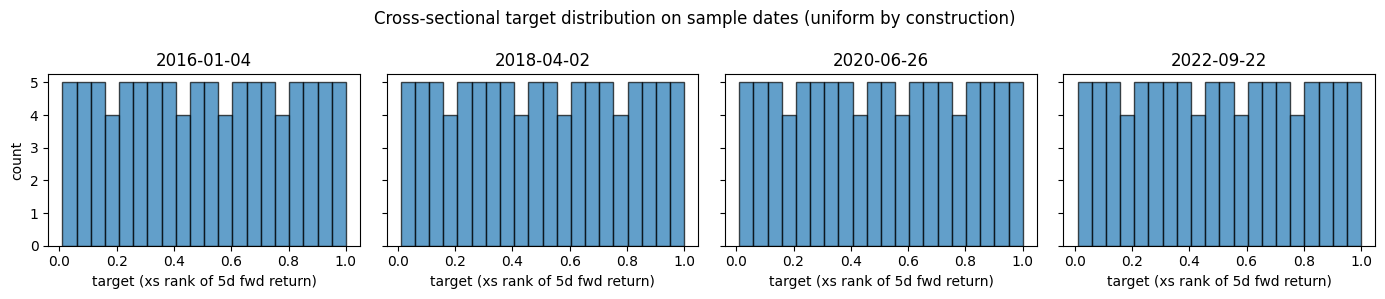

In [16]:
# Visualize target distribution on a few representative dates.
rep_dates = sorted(DATASET['date'].unique())[::len(DATASET['date'].unique())//4][:4]
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, d in zip(axes, rep_dates):
    sub = DATASET[DATASET['date'] == d]
    ax.hist(sub['target'], bins=20, alpha=0.7, edgecolor="black")
    ax.set_title(str(pd.Timestamp(d).date()))
    ax.set_xlabel("target (xs rank of 5d fwd return)")
axes[0].set_ylabel("count")
fig.suptitle("Cross-sectional target distribution on sample dates (uniform by construction)")
plt.tight_layout(); plt.show()


---

## Phase 4 — Walk-forward split protocol

Financial time-series demand **walk-forward evaluation** rather than random train/test splits. Each test window uses only data strictly prior to its start for training. We roll forward in 3-month steps across the full period, generating multiple out-of-sample evaluations. The aggregated test-period predictions form our official OOS signal for all downstream evaluation and portfolio construction.


In [17]:
@dataclass
class WFWindow:
    train_start: pd.Timestamp
    train_end:   pd.Timestamp
    val_start:   pd.Timestamp
    val_end:     pd.Timestamp
    test_start:  pd.Timestamp
    test_end:    pd.Timestamp

def build_walk_forward(min_date, max_date,
                       train_days, val_days, test_days, step_days) -> List[WFWindow]:
    windows = []
    cursor = pd.Timestamp(min_date) + pd.Timedelta(days=train_days + val_days)
    while cursor + pd.Timedelta(days=test_days) <= pd.Timestamp(max_date):
        test_start = cursor
        test_end   = cursor + pd.Timedelta(days=test_days)
        val_end    = test_start
        val_start  = val_end - pd.Timedelta(days=val_days)
        train_end  = val_start
        train_start = train_end - pd.Timedelta(days=train_days)
        windows.append(WFWindow(train_start, train_end, val_start, val_end, test_start, test_end))
        cursor = cursor + pd.Timedelta(days=step_days)
    return windows

WINDOWS = build_walk_forward(
    DATASET['date'].min(), DATASET['date'].max(),
    TRAIN_DAYS, VAL_DAYS, TEST_DAYS, STEP_DAYS,
)
print(f"Generated {len(WINDOWS)} walk-forward windows.\n")
for i, w in enumerate(WINDOWS):
    print(f"  W{i:02d}: train {w.train_start.date()}->{w.train_end.date()} | "
          f"val {w.val_start.date()}->{w.val_end.date()} | "
          f"test {w.test_start.date()}->{w.test_end.date()}")


Generated 23 walk-forward windows.

  W00: train 2016-01-04->2019-01-03 | val 2019-01-03->2019-04-03 | test 2019-04-03->2019-07-02
  W01: train 2016-04-03->2019-04-03 | val 2019-04-03->2019-07-02 | test 2019-07-02->2019-09-30
  W02: train 2016-07-02->2019-07-02 | val 2019-07-02->2019-09-30 | test 2019-09-30->2019-12-29
  W03: train 2016-09-30->2019-09-30 | val 2019-09-30->2019-12-29 | test 2019-12-29->2020-03-28
  W04: train 2016-12-29->2019-12-29 | val 2019-12-29->2020-03-28 | test 2020-03-28->2020-06-26
  W05: train 2017-03-29->2020-03-28 | val 2020-03-28->2020-06-26 | test 2020-06-26->2020-09-24
  W06: train 2017-06-27->2020-06-26 | val 2020-06-26->2020-09-24 | test 2020-09-24->2020-12-23
  W07: train 2017-09-25->2020-09-24 | val 2020-09-24->2020-12-23 | test 2020-12-23->2021-03-23
  W08: train 2017-12-24->2020-12-23 | val 2020-12-23->2021-03-23 | test 2021-03-23->2021-06-21
  W09: train 2018-03-24->2021-03-23 | val 2021-03-23->2021-06-21 | test 2021-06-21->2021-09-19
  W10: train 2

In [18]:
def slice_window(df: pd.DataFrame, w: WFWindow):
    tr = df[(df['date'] >= w.train_start) & (df['date'] < w.train_end)]
    va = df[(df['date'] >= w.val_start)   & (df['date'] < w.val_end)]
    te = df[(df['date'] >= w.test_start)  & (df['date'] < w.test_end)]
    return tr, va, te

# Quick sanity check on one window
tr, va, te = slice_window(DATASET, WINDOWS[0])
print(f"Window 0 sizes: train={len(tr):,}  val={len(va):,}  test={len(te):,}")


Window 0 sizes: train=72,480  val=5,952  test=5,952


---

## Phase 5 — Model A: LightGBM baseline

LightGBM is a gradient-boosted-trees library that handles tabular cross-sectional features well and is the de-facto baseline in equity ML research. We train one model per walk-forward window with early-stopping on the validation set, then score the held-out test set.


In [19]:
LGB_PARAMS = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.03,
    "num_leaves": 63,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_data_in_leaf": 200,
    "lambda_l2": 1.0,
    "verbose": -1,
    "seed": SEED,
}

def train_lgb_window(tr, va, features, target="target"):
    dtr = lgb.Dataset(tr[features].values, label=tr[target].values)
    dva = lgb.Dataset(va[features].values, label=va[target].values, reference=dtr)
    model = lgb.train(
        LGB_PARAMS, dtr,
        num_boost_round=800,
        valid_sets=[dtr, dva],
        valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(0)],
    )
    return model

lgb_models = []
lgb_preds = []

print("Training LightGBM across walk-forward windows...")
for i, w in enumerate(WINDOWS):
    tr, va, te = slice_window(DATASET, w)
    if len(tr) < 10_000 or len(va) < 500 or len(te) < 500:
        print(f"  W{i:02d}: insufficient data, skipping")
        continue
    model = train_lgb_window(tr, va, FEATURE_COLS)
    te = te.copy()
    te["pred_lgb"] = model.predict(te[FEATURE_COLS].values, num_iteration=model.best_iteration)
    lgb_preds.append(te[["date", "ticker", "target", "fwd_ret", "pred_lgb"]])
    lgb_models.append(model)
    print(f"  W{i:02d}: trees={model.best_iteration}  val_rmse={model.best_score['val']['rmse']:.4f}  test_rows={len(te):,}")

PRED_LGB = pd.concat(lgb_preds, ignore_index=True)
print(f"\nLightGBM OOS predictions: {PRED_LGB.shape}")


Training LightGBM across walk-forward windows...
  W00: trees=32  val_rmse=0.2886  test_rows=5,952
  W01: trees=1  val_rmse=0.2887  test_rows=5,952
  W02: trees=2  val_rmse=0.2886  test_rows=6,048
  W03: trees=4  val_rmse=0.2886  test_rows=5,952
  W04: trees=3  val_rmse=0.2886  test_rows=5,952
  W05: trees=30  val_rmse=0.2865  test_rows=5,952
  W06: trees=15  val_rmse=0.2884  test_rows=6,048
  W07: trees=10  val_rmse=0.2886  test_rows=5,760
  W08: trees=9  val_rmse=0.2886  test_rows=5,952
  W09: trees=33  val_rmse=0.2885  test_rows=6,048
  W10: trees=11  val_rmse=0.2887  test_rows=6,144
  W11: trees=7  val_rmse=0.2886  test_rows=5,856
  W12: trees=1  val_rmse=0.2887  test_rows=5,952
  W13: trees=5  val_rmse=0.2887  test_rows=5,856
  W14: trees=7  val_rmse=0.2885  test_rows=6,048
  W15: trees=5  val_rmse=0.2887  test_rows=5,760
  W16: trees=1  val_rmse=0.2887  test_rows=6,048
  W17: trees=66  val_rmse=0.2880  test_rows=5,952
  W18: trees=1  val_rmse=0.2887  test_rows=6,048
  W19: trees=

---

## Phase 6 — Model B: LSTM

The LSTM consumes a sequence of the last 20 trading days of features for each (ticker, date) observation and produces a scalar score. Unlike LightGBM, which treats each row independently, the LSTM can exploit temporal structure in the feature evolution. We use a modest architecture (2 layers, 64 hidden units, dropout 0.2) that trains in a few minutes on the free Colab GPU (or a few tens of minutes on CPU).


In [20]:
SEQ_LEN = 20  # days of history per observation

class PanelSeqDataset(Dataset):
    '''Builds sequences of length SEQ_LEN for each (ticker, date) row.

    We pre-index by (ticker -> sorted dates) to build sequences efficiently.
    '''
    def __init__(self, df: pd.DataFrame, feature_cols: List[str], seq_len: int = SEQ_LEN):
        self.seq_len = seq_len
        self.feature_cols = feature_cols
        # Build per-ticker sorted feature arrays
        df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
        self.index = []   # list of (ticker, row_in_feat_array)
        self.feats = {}   # ticker -> np.ndarray [T, F]
        self.targets = {} # ticker -> np.ndarray [T]
        self.dates = {}
        for t, sub in df.groupby("ticker"):
            self.feats[t] = sub[feature_cols].values.astype(np.float32)
            self.targets[t] = sub["target"].values.astype(np.float32)
            self.dates[t] = sub["date"].values
            # We can only produce a sample at row i if i >= seq_len - 1
            for i in range(seq_len - 1, len(sub)):
                self.index.append((t, i))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        t, i = self.index[idx]
        x = self.feats[t][i - self.seq_len + 1 : i + 1]   # [seq_len, F]
        y = self.targets[t][i]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


class LSTMScorer(nn.Module):
    def __init__(self, n_features: int, hidden: int = 64, layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=layers, batch_first=True, dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)


In [21]:
def train_lstm_window(tr, va, te, feature_cols,
                      batch_size=512, max_epochs=15, patience=3, lr=1e-3):
    # Standardize features using train-only statistics (no leakage)
    mu = tr[feature_cols].mean().values.astype(np.float32)
    sd = tr[feature_cols].std().values.astype(np.float32) + 1e-6

    def _std(df):
        df = df.copy()
        df[feature_cols] = (df[feature_cols].values - mu) / sd
        return df

    ds_tr = PanelSeqDataset(_std(tr), feature_cols)
    ds_va = PanelSeqDataset(_std(va), feature_cols)
    ds_te = PanelSeqDataset(_std(te), feature_cols)

    if len(ds_tr) == 0 or len(ds_va) == 0:
        return None, None

    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=0)
    dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0)

    model = LSTMScorer(n_features=len(feature_cols)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        for x, y in dl_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            yhat = model(x)
            loss = loss_fn(yhat, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # Validation
        model.eval()
        with torch.no_grad():
            vl = 0.0; n = 0
            for x, y in dl_va:
                x, y = x.to(DEVICE), y.to(DEVICE)
                yhat = model(x)
                vl += loss_fn(yhat, y).item() * len(y)
                n += len(y)
            vl = vl / max(n, 1)

        if vl < best_val - 1e-5:
            best_val = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Predict on test
    model.eval()
    preds = []
    with torch.no_grad():
        for x, _ in dl_te:
            x = x.to(DEVICE)
            preds.append(model(x).cpu().numpy())
    preds = np.concatenate(preds) if preds else np.array([])

    # Map predictions back to (ticker, date) rows of te (same order as PanelSeqDataset.index)
    te_sorted = te.sort_values(["ticker", "date"]).reset_index(drop=True)
    index = []
    for t, sub in te_sorted.groupby("ticker"):
        for i in range(SEQ_LEN - 1, len(sub)):
            index.append((t, sub["date"].iloc[i]))

    te_preds = pd.DataFrame(index, columns=["ticker", "date"])
    te_preds["pred_lstm"] = preds
    return model, te_preds


In [22]:
print("Training LSTM across walk-forward windows (this takes a few minutes)...")
lstm_preds = []
for i, w in enumerate(WINDOWS):
    tr, va, te = slice_window(DATASET, w)
    if len(tr) < 10_000 or len(va) < 500 or len(te) < 500:
        continue
    model, te_pred = train_lstm_window(tr, va, te, FEATURE_COLS)
    if te_pred is None:
        continue
    # Merge predictions back onto the test slice
    merged = te.merge(te_pred, on=["ticker", "date"], how="inner")
    lstm_preds.append(merged[["date", "ticker", "target", "fwd_ret", "pred_lstm"]])
    print(f"  W{i:02d}: test_rows_with_seq={len(merged):,}")

PRED_LSTM = pd.concat(lstm_preds, ignore_index=True) if lstm_preds else pd.DataFrame()
print(f"\nLSTM OOS predictions: {PRED_LSTM.shape}")


Training LSTM across walk-forward windows (this takes a few minutes)...
  W00: test_rows_with_seq=4,128
  W01: test_rows_with_seq=4,128
  W02: test_rows_with_seq=4,224
  W03: test_rows_with_seq=4,128
  W04: test_rows_with_seq=4,128
  W05: test_rows_with_seq=4,128
  W06: test_rows_with_seq=4,224
  W07: test_rows_with_seq=3,936
  W08: test_rows_with_seq=4,128
  W09: test_rows_with_seq=4,224
  W10: test_rows_with_seq=4,320
  W11: test_rows_with_seq=4,032
  W12: test_rows_with_seq=4,128
  W13: test_rows_with_seq=4,032
  W14: test_rows_with_seq=4,224
  W15: test_rows_with_seq=3,936
  W16: test_rows_with_seq=4,224
  W17: test_rows_with_seq=4,128
  W18: test_rows_with_seq=4,224
  W19: test_rows_with_seq=3,936
  W20: test_rows_with_seq=4,128
  W21: test_rows_with_seq=4,032
  W22: test_rows_with_seq=4,224

LSTM OOS predictions: (94944, 5)


---

## Phase 7 — Rank-blend ensemble

Blending diverse model predictions on rank rather than raw score is a standard technique; it is robust to models producing scores on different scales. We average the cross-sectional ranks of LightGBM and LSTM predictions per date.


In [23]:
def xs_rank(df, col):
    return df.groupby("date")[col].rank(pct=True)

# Align predictions on (date, ticker)
PRED = PRED_LGB.merge(PRED_LSTM[["date", "ticker", "pred_lstm"]],
                      on=["date", "ticker"], how="inner")

PRED["rank_lgb"]  = xs_rank(PRED, "pred_lgb")
PRED["rank_lstm"] = xs_rank(PRED, "pred_lstm")
PRED["pred_ens"]  = (PRED["rank_lgb"] + PRED["rank_lstm"]) / 2

print(f"Aligned prediction panel: {PRED.shape}")
print(PRED.head())


Aligned prediction panel: (94944, 9)
        date ticker    target   fwd_ret  pred_lgb  pred_lstm  rank_lgb  \
0 2019-05-01   AAPL  0.156250 -0.036196  0.544472   0.512760  0.989583   
1 2019-05-02   AAPL  0.125000 -0.040306  0.536094   0.509467  0.968750   
2 2019-05-03   AAPL  0.062500 -0.065221  0.538096   0.509097  0.989583   
3 2019-05-06   AAPL  0.062500 -0.105741  0.534610   0.503689  0.947917   
4 2019-05-07   AAPL  0.041667 -0.066418  0.535361   0.499404  0.947917   

   rank_lstm  pred_ens  
0   0.468750  0.729167  
1   0.468750  0.718750  
2   0.427083  0.708333  
3   0.302083  0.625000  
4   0.260417  0.604167  


---

## Phase 8 — Evaluation

We evaluate each model family on three layers:

1. **Signal quality**: information coefficient (IC — Pearson correlation between prediction and realized forward return) and rank IC (Spearman). Computed per-date, then averaged.
2. **Portfolio performance**: a simple decile long-short portfolio (long top-10% predictions, short bottom-10%, equal-weighted within each leg, rebalanced every 5 trading days) gives annualized Sharpe ratio, maximum drawdown, and realized turnover.
3. **Aggregated comparison**: side-by-side table of LightGBM, LSTM, ensemble.


In [24]:
def compute_ic(df, pred_col, ret_col="fwd_ret"):
    '''Daily IC (Pearson) and rank IC (Spearman), aggregated.'''
    daily_ic  = df.groupby("date").apply(
        lambda g: g[pred_col].corr(g[ret_col]) if len(g) > 5 else np.nan,
        include_groups=False # Added to suppress deprecation warning
    )
    daily_ric = df.groupby("date").apply(
        lambda g: g[pred_col].corr(g[ret_col], method="spearman") if len(g) > 5 else np.nan,
        include_groups=False # Added to suppress deprecation warning
    )
    return {
        "IC_mean":  daily_ic.mean(),
        "IC_std":   daily_ic.std(),
        "IC_ir":    daily_ic.mean() / (daily_ic.std() + 1e-9),
        "RankIC":   daily_ric.mean(),
        "RankIC_std": daily_ric.std(),
    }, daily_ic, daily_ric


def decile_long_short_backtest(df, pred_col, ret_col="fwd_ret", top_q=0.10, bot_q=0.10):
    '''Decile long-short portfolio return per date.

    Signal at date t predicts fwd_ret over [t, t+H]; we treat the per-date L-S as
    the return earned by holding the sleeve for H days. For reporting we scale to
    daily using H.
    '''
    rows = []
    for d, g in df.groupby("date"):
        if len(g) < 10:
            continue
        top_k = max(1, int(len(g) * top_q))
        bot_k = max(1, int(len(g) * bot_q))
        g = g.copy()
        g["rk"] = g[pred_col].rank(pct=True)
        longs  = g.nlargest(top_k, "rk")
        shorts = g.nsmallest(bot_k, "rk")
        ls_ret = longs[ret_col].mean() - shorts[ret_col].mean()
        rows.append({"date": d, "ls_ret": ls_ret,
                     "long_names": tuple(longs["ticker"]),
                     "short_names": tuple(shorts["ticker"])})
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)


def backtest_metrics(ls_df, horizon=FORWARD_HORIZON):
    '''Convert H-day sleeve returns into annualized metrics.

    The sleeve is rebalanced every horizon days in the ideal case; for a conservative
    view we assume daily rebalancing with the most recent H-day signal (overlapping
    positions). We scale per-period return to daily by dividing by H, then annualize.
    '''
    if len(ls_df) == 0:
        return {}
    daily_equiv = ls_df["ls_ret"].values / horizon
    ann_ret = np.nanmean(daily_equiv) * 252
    ann_vol = np.nanstd(daily_equiv) * math.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    cum = np.cumprod(1 + daily_equiv)
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    mdd = dd.min()

    # Turnover: fraction of names in top/bot sleeves that change between consecutive dates
    turnovers = []
    for i in range(1, len(ls_df)):
        prev_long = set(ls_df.iloc[i-1]["long_names"])
        cur_long  = set(ls_df.iloc[i]["long_names"])
        prev_short = set(ls_df.iloc[i-1]["short_names"])
        cur_short = set(ls_df.iloc[i]["short_names"])
        turnover = 0.5 * (len(prev_long.symmetric_difference(cur_long)) / max(len(cur_long),1)
                        + len(prev_short.symmetric_difference(cur_short)) / max(len(cur_short),1))
        turnovers.append(turnover)
    avg_turnover = float(np.mean(turnovers)) if turnovers else np.nan

    return {
        "ann_return": ann_ret, "ann_vol": ann_vol, "sharpe": sharpe,
        "max_drawdown": mdd, "avg_daily_turnover": avg_turnover,
        "n_periods": len(ls_df),
    }

In [25]:
# Run evaluation for each model
results = {}
for label, col in [("LightGBM", "pred_lgb"), ("LSTM", "pred_lstm"), ("Ensemble", "pred_ens")]:
    ic_summary, daily_ic, daily_ric = compute_ic(PRED, col)
    ls_df = decile_long_short_backtest(PRED, col)
    bt = backtest_metrics(ls_df)
    results[label] = {**ic_summary, **bt, "_ls_df": ls_df, "_daily_ic": daily_ic}

summary = pd.DataFrame({
    k: {kk: vv for kk, vv in v.items() if not kk.startswith("_")}
    for k, v in results.items()
}).T
print("Model comparison on OOS window (all models, pre-overlay):")
print(summary[["IC_mean","IC_ir","RankIC","sharpe","ann_return","ann_vol","max_drawdown","avg_daily_turnover"]].round(4).to_string())

Model comparison on OOS window (all models, pre-overlay):
          IC_mean   IC_ir  RankIC  sharpe  ann_return  ann_vol  max_drawdown  avg_daily_turnover
LightGBM   0.0152  0.0912  0.0127  1.2192      0.1082   0.0887       -0.1317              0.7904
LSTM       0.0221  0.1136  0.0249  1.9955      0.1958   0.0981       -0.1594              0.4100
Ensemble   0.0218  0.1208  0.0231  1.4518      0.1475   0.1016       -0.2065              0.6470


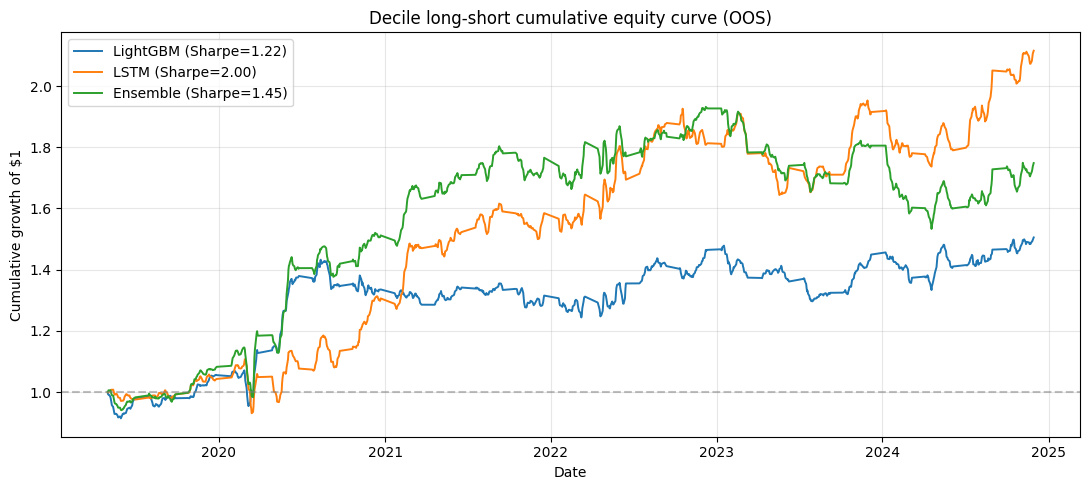

In [26]:
# Cumulative-return curves for the three models
fig, ax = plt.subplots(figsize=(11, 5))
for label in ["LightGBM", "LSTM", "Ensemble"]:
    ls = results[label]["_ls_df"]
    daily_equiv = ls["ls_ret"].values / FORWARD_HORIZON
    cum = np.cumprod(1 + daily_equiv)
    ax.plot(ls["date"], cum, label=f"{label} (Sharpe={results[label]['sharpe']:.2f})", linewidth=1.4)
ax.axhline(1.0, linestyle="--", color="grey", alpha=0.5)
ax.set_title("Decile long-short cumulative equity curve (OOS)")
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
ax.legend(loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


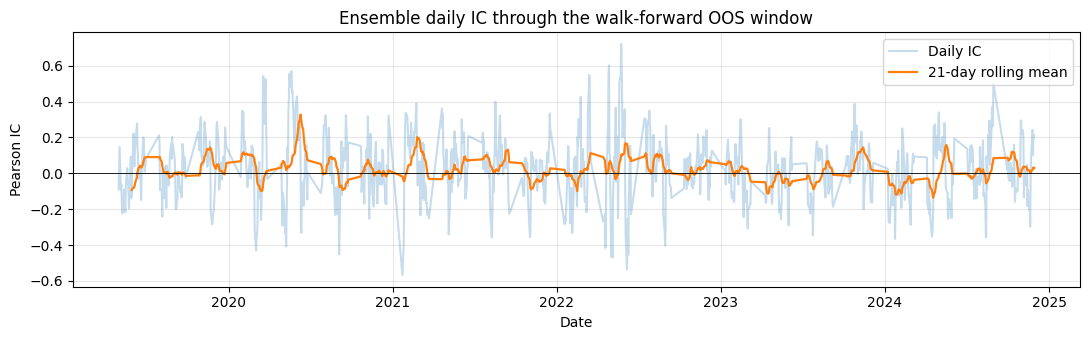

In [27]:
# Rolling IC chart for the ensemble
fig, ax = plt.subplots(figsize=(11, 3.5))
ic = results["Ensemble"]["_daily_ic"]
ic_roll = ic.rolling(21).mean()
ax.plot(ic.index, ic.values, alpha=0.25, label="Daily IC")
ax.plot(ic_roll.index, ic_roll.values, linewidth=1.6, label="21-day rolling mean")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Ensemble daily IC through the walk-forward OOS window")
ax.set_xlabel("Date"); ax.set_ylabel("Pearson IC")
ax.legend(loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---

## Phase 9 — Thematic overlay from published macro-research

### Design

A **thematic overlay** is a post-prediction adjustment that tilts the model's cross-sectional ranking toward or away from sectors aligned with a stated macro thesis. The overlay is intentionally **orthogonal to the ML model**: the ML learns short-horizon cross-sectional forward-return patterns from market-microstructure features; the overlay encodes a **long-horizon macro view** that a human analyst forms from published research.

This separation of concerns is important because:
1. It keeps the ML attribution clean — we can quantify marginal alpha contribution from overlay alone.
2. It makes the overlay legible to compliance and portfolio-management reviewers — each tilt has a named source.
3. It is the structure a real equity research analyst would use: ML as a scoring engine, macro view as a sector exposure decision.

### Theme sources

Themes referenced below are drawn from publicly-released research-house surveys and insight publications. **No proprietary content is reproduced**; only the high-level thematic orientation (bullish / bearish a sector) informs the tilt.

| Theme | Tilt rationale (publicly-sourced) | Sectors tilted |
| --- | --- | --- |
| AI infrastructure capex | Multiple research houses including HSBC Global Research have published on the AI capex cycle through 2024-2026. | **+** Information Technology, Communication Services |
| Energy storage and transition | HSBC Global Research "Energy storage – The great enabler" (March 2026) and related sustainability-transition publications. | **+** Utilities, Industrials; neutral Materials |
| Healthcare and aging | Broad-based research on healthcare demand from demographic drivers. | **+** Health Care |
| Energy transition crowding out legacy oil & gas | Per published net-zero transition commentary. | **–** Energy (modest) |

Each tilt is implemented as a multiplicative score adjustment applied to the model's cross-sectional rank, then re-ranked. Tilt magnitudes are bounded so the overlay cannot fully override the ML signal — it acts as a *lean*, not a *switch*.


In [28]:
# Theme definitions: (theme_name, sector -> tilt_factor mapping)
# Tilt factor is multiplicative on the ranked score, centered on 1.0.
# Effective range: ~0.85 (moderate underweight) to ~1.15 (moderate overweight).

THEMES = {
    "AI infrastructure capex": {
        "Information Technology": 1.12,
        "Communication Services": 1.08,
    },
    "Energy storage and transition": {
        "Utilities":   1.10,
        "Industrials": 1.08,
    },
    "Healthcare and aging": {
        "Health Care": 1.10,
    },
    "Legacy energy headwind": {
        "Energy": 0.90,
    },
}

# Combine themes into a single sector -> cumulative tilt factor map
combined_tilt: Dict[str, float] = {}
for theme, sec_map in THEMES.items():
    for sec, f in sec_map.items():
        combined_tilt[sec] = combined_tilt.get(sec, 1.0) * f

print("Combined sector tilt factors (product across themes):")
for s, f in sorted(combined_tilt.items(), key=lambda x: -x[1]):
    print(f"  {s:28s}  x {f:.3f}")
print("  (sectors not listed have tilt factor = 1.000, i.e., neutral)")


Combined sector tilt factors (product across themes):
  Information Technology        x 1.120
  Utilities                     x 1.100
  Health Care                   x 1.100
  Communication Services        x 1.080
  Industrials                   x 1.080
  Energy                        x 0.900
  (sectors not listed have tilt factor = 1.000, i.e., neutral)


In [29]:
# Apply overlay: multiply ensemble score by sector tilt, then re-rank per date.
PRED["sector"] = PRED["ticker"].map(UNIVERSE_WITH_SECTOR)
PRED["tilt"]   = PRED["sector"].map(combined_tilt).fillna(1.0)
PRED["pred_ens_tilt"] = PRED["pred_ens"] * PRED["tilt"]

# Evaluate both overlay-off and overlay-on
res_no_overlay = {}
res_with_overlay = {}

for col, store, label in [
    ("pred_ens",      res_no_overlay,   "Ensemble (no overlay)"),
    ("pred_ens_tilt", res_with_overlay, "Ensemble + thematic overlay"),
]:
    ic_summary, _, _ = compute_ic(PRED, col)
    ls_df = decile_long_short_backtest(PRED, col)
    bt = backtest_metrics(ls_df)
    store.update({**ic_summary, **bt, "_ls_df": ls_df, "_label": label})

comp = pd.DataFrame([
    {"config": res_no_overlay["_label"],   **{k: v for k, v in res_no_overlay.items()   if not k.startswith("_")}},
    {"config": res_with_overlay["_label"], **{k: v for k, v in res_with_overlay.items() if not k.startswith("_")}},
])
print("\nOverlay comparison:")
print(comp[["config","IC_mean","IC_ir","RankIC","sharpe","ann_return","ann_vol","max_drawdown","avg_daily_turnover"]].round(4).to_string(index=False))



Overlay comparison:
                     config  IC_mean  IC_ir  RankIC  sharpe  ann_return  ann_vol  max_drawdown  avg_daily_turnover
      Ensemble (no overlay)   0.0218 0.1208  0.0231  1.4518      0.1475   0.1016       -0.2065              0.6470
Ensemble + thematic overlay   0.0238 0.1325  0.0253  1.8548      0.1809   0.0976       -0.1295              0.6329


### Performance by Market Regime

To understand how the model performs under different market conditions, we categorize market regimes based on the rolling volatility of the S&P 500 (SPY). We define 'Low Volatility', 'Medium Volatility', and 'High Volatility' regimes based on quantiles of a 60-day rolling standard deviation of SPY returns. We then analyze the Information Coefficient (IC) and Sharpe Ratio for the 'Ensemble + Thematic Overlay' model within each regime.

In [30]:
# Load SPY data (already cached)
import pickle
spy_cache = CACHE_DIR / "spy_ohlcv.pkl"
with open(spy_cache, "rb") as f:
    spy = pickle.load(f)

# Ensure date column is datetime and calculate daily returns
spy["date"] = pd.to_datetime(spy["date"])
spy["spy_ret"] = spy["spy_close"].pct_change(1)

# Calculate rolling 60-day volatility for SPY
spy["spy_vol_60d"] = spy["spy_ret"].rolling(window=60).std()

# Merge SPY volatility with prediction data
PRED_with_vol = PRED.merge(spy[["date", "spy_vol_60d"]], on="date", how="left")
PRED_with_vol = PRED_with_vol.dropna(subset=["spy_vol_60d"])

# Define volatility regimes based on quantiles
vol_q = PRED_with_vol["spy_vol_60d"].quantile([0.33, 0.66])

def get_vol_regime(vol):
    if vol <= vol_q[0.33]:
        return "Low Volatility"
    elif vol <= vol_q[0.66]:
        return "Medium Volatility"
    else:
        return "High Volatility"

PRED_with_vol["vol_regime"] = PRED_with_vol["spy_vol_60d"].apply(get_vol_regime)

print("Volatility regime distribution:")
print(PRED_with_vol["vol_regime"].value_counts())

# Calculate performance metrics for each regime
regime_results = []
for regime in sorted(PRED_with_vol["vol_regime"].unique()):
    regime_df = PRED_with_vol[PRED_with_vol["vol_regime"] == regime]
    if len(regime_df) > 50: # Ensure enough data for meaningful metrics
        ic_summary, _, _ = compute_ic(regime_df, "pred_ens_tilt")
        ls_df = decile_long_short_backtest(regime_df, "pred_ens_tilt")
        bt = backtest_metrics(ls_df)
        regime_results.append({"Regime": regime, **ic_summary, **bt})

regime_summary_df = pd.DataFrame(regime_results)
print("\nModel performance by market regime (Ensemble + Thematic Overlay):")
print(regime_summary_df[["Regime", "IC_mean", "IC_ir", "sharpe", "ann_return", "ann_vol", "max_drawdown"]].round(4).to_string(index=False))

Volatility regime distribution:
vol_regime
High Volatility      32256
Low Volatility       31392
Medium Volatility    31296
Name: count, dtype: int64

Model performance by market regime (Ensemble + Thematic Overlay):
           Regime  IC_mean  IC_ir  sharpe  ann_return  ann_vol  max_drawdown
  High Volatility   0.0353 0.1666  2.4547      0.3237   0.1319       -0.0709
   Low Volatility   0.0063 0.0410 -0.1502     -0.0105   0.0697       -0.1740
Medium Volatility   0.0294 0.1783  2.9569      0.2258   0.0764       -0.0751


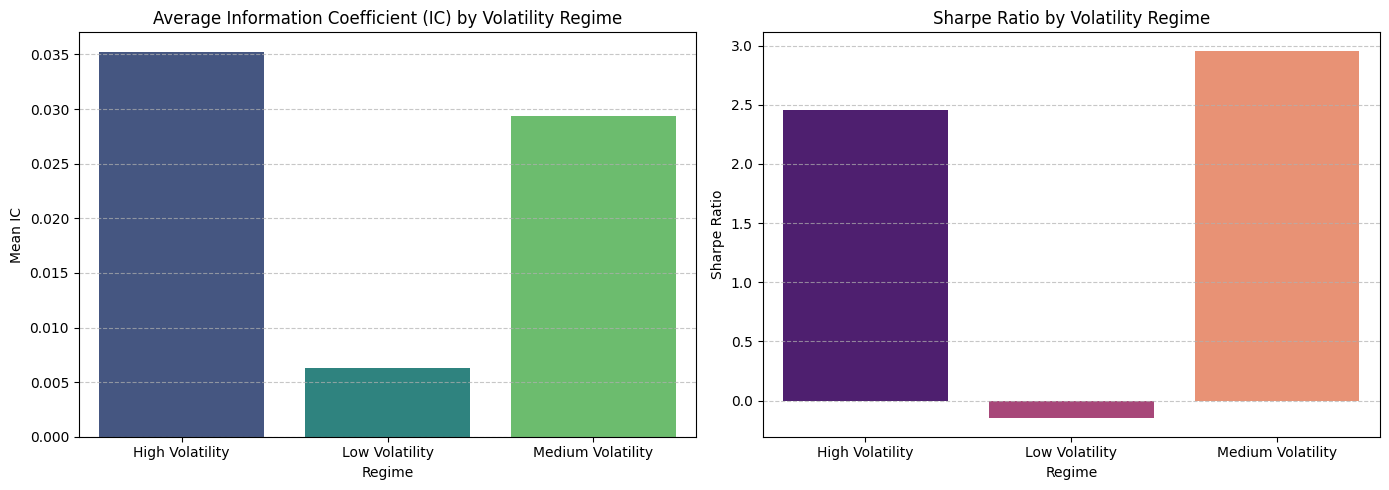

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot IC_mean by regime
sns.barplot(x='Regime', y='IC_mean', data=regime_summary_df, palette='viridis', ax=axes[0])
axes[0].set_title('Average Information Coefficient (IC) by Volatility Regime')
axes[0].set_ylabel('Mean IC')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Sharpe by regime
sns.barplot(x='Regime', y='sharpe', data=regime_summary_df, palette='magma', ax=axes[1])
axes[1].set_title('Sharpe Ratio by Volatility Regime')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

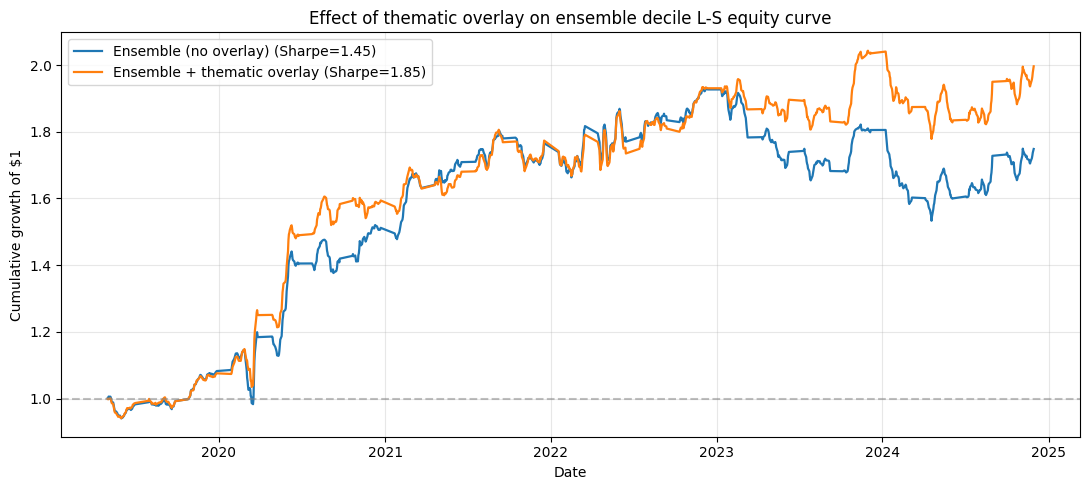

In [32]:
# Visualize overlay effect
fig, ax = plt.subplots(figsize=(11, 5))
for store, colr in [(res_no_overlay, "tab:blue"), (res_with_overlay, "tab:orange")]:
    ls = store["_ls_df"]
    daily_equiv = ls["ls_ret"].values / FORWARD_HORIZON
    cum = np.cumprod(1 + daily_equiv)
    ax.plot(ls["date"], cum, label=f"{store['_label']} (Sharpe={store['sharpe']:.2f})",
            color=colr, linewidth=1.6)
ax.axhline(1.0, linestyle="--", color="grey", alpha=0.5)
ax.set_title("Effect of thematic overlay on ensemble decile L-S equity curve")
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
ax.legend(loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Portfolio Performance Over Time (for Non-Technical Stakeholders)

This plot illustrates the hypothetical growth of a $1 investment in the decile long-short portfolio, comparing the ensemble model's performance with and without the thematic overlay. It provides a clear visual representation of the overall return profile and the additional benefit gained from incorporating macro research signals.

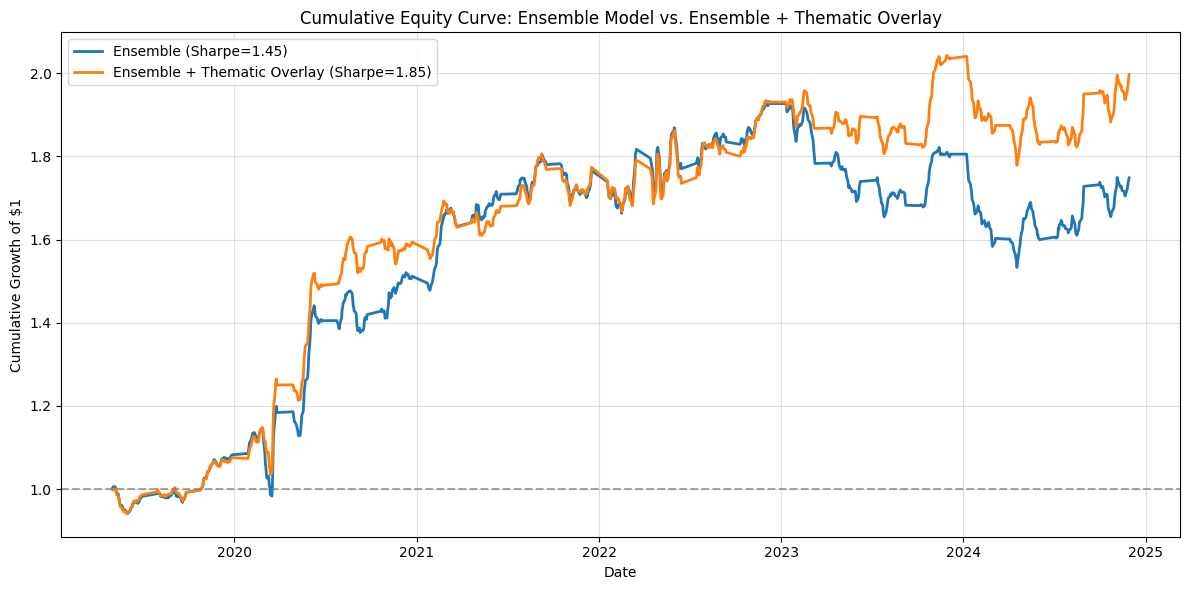

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting the ensemble without overlay
ls_no_overlay = res_no_overlay["_ls_df"]
daily_equiv_no_overlay = ls_no_overlay["ls_ret"].values / FORWARD_HORIZON
cum_no_overlay = np.cumprod(1 + daily_equiv_no_overlay)
ax.plot(ls_no_overlay["date"], cum_no_overlay, label=f"Ensemble (Sharpe={res_no_overlay['sharpe']:.2f})", color="tab:blue", linewidth=2)

# Plotting the ensemble with thematic overlay
ls_with_overlay = res_with_overlay["_ls_df"]
daily_equiv_with_overlay = ls_with_overlay["ls_ret"].values / FORWARD_HORIZON
cum_with_overlay = np.cumprod(1 + daily_equiv_with_overlay)
ax.plot(ls_with_overlay["date"], cum_with_overlay, label=f"Ensemble + Thematic Overlay (Sharpe={res_with_overlay['sharpe']:.2f})", color="tab:orange", linewidth=2)

ax.axhline(1.0, linestyle="--", color="grey", alpha=0.7)
ax.set_title("Cumulative Equity Curve: Ensemble Model vs. Ensemble + Thematic Overlay")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Growth of $1")
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Sector-Level Performance Analysis

To understand which sectors contribute most to the overall strategy, we analyze the performance of a decile long-short strategy *within each sector*.

This plot shows the hypothetical cumulative growth of $1 invested in a sector-specific long-short portfolio, based on the `Ensemble + Thematic Overlay` signal. It helps identify consistently strong or weak performing sectors under the model's guidance.

**Methodology note.** A within-sector decile long-short is only statistically meaningful when the sector has enough names on a given date to form credible top- and bottom-decile groups. We therefore require at least **8 distinct tickers in a sector on each date** before computing a sector-date spread; sectors that fail this threshold on a given date are excluded for that date. In our fixed universe this excludes the small sectors (Communication Services, Energy, Utilities, Materials, Real Estate), which each contain 3–7 names — a 10%-decile in those sectors collapses to a 1-vs-1 pairwise spread, which is noise rather than a meaningful strategy signal. Restricting the analysis to sufficiently populated sectors preserves statistical meaning in the reported equity curves.


Sectors excluded on some dates due to <8 names available:
  Communication Services       excluded on 989 date(s)
  Energy                       excluded on 989 date(s)
  Materials                    excluded on 989 date(s)
  Real Estate                  excluded on 989 date(s)
  Utilities                    excluded on 989 date(s)

Sectors included in within-sector L/S analysis: ['Consumer Discretionary', 'Consumer Staples', 'Financials', 'Health Care', 'Industrials', 'Information Technology']


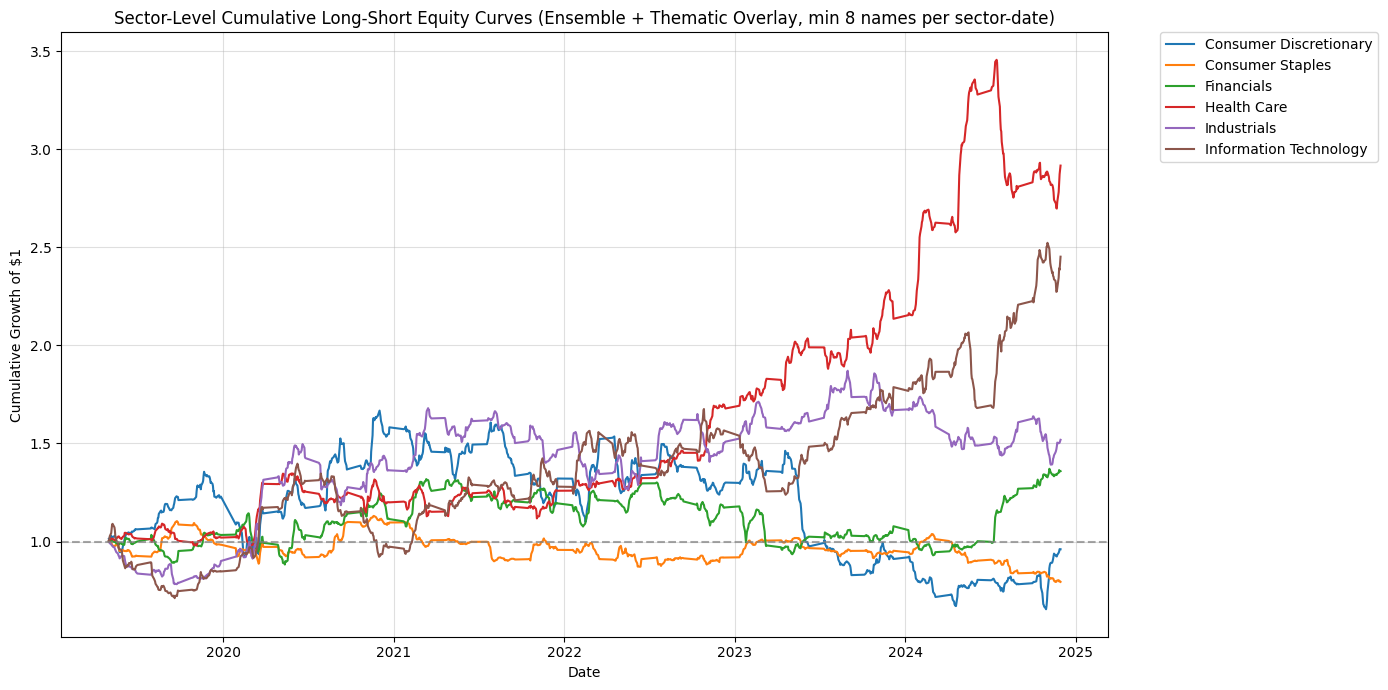

In [34]:
# Sector-level decile long-short: require at least MIN_NAMES distinct tickers
# in the sector on a given date to form credible top/bottom deciles.
MIN_NAMES_PER_SECTOR_DATE = 8

sector_daily_metrics = []
excluded_counts = {}  # sector -> # dates excluded for small-N

for d, date_group in PRED.groupby("date"):
    for sector, sector_df in date_group.groupby("sector"):
        n_names = sector_df["ticker"].nunique()
        if n_names < MIN_NAMES_PER_SECTOR_DATE:
            excluded_counts[sector] = excluded_counts.get(sector, 0) + 1
            continue

        sector_df_copy = sector_df.copy()
        sector_df_copy["rank"] = sector_df_copy["pred_ens_tilt"].rank(pct=True)

        top_k_count = max(1, int(n_names * 0.10))
        bot_k_count = max(1, int(n_names * 0.10))

        longs  = sector_df_copy.nlargest(top_k_count, "rank")
        shorts = sector_df_copy.nsmallest(bot_k_count, "rank")

        ls_ret = longs["fwd_ret"].mean() - shorts["fwd_ret"].mean()

        sector_daily_metrics.append({
            "date": d,
            "sector": sector,
            "n_names": n_names,
            "ls_ret": ls_ret,
        })

sector_performance_df = pd.DataFrame(sector_daily_metrics)
sector_performance_df["daily_equiv"] = sector_performance_df["ls_ret"] / FORWARD_HORIZON
sector_performance_df = sector_performance_df.sort_values(["sector", "date"])

# Report which sectors were excluded and on how many dates
if excluded_counts:
    print(f"Sectors excluded on some dates due to <{MIN_NAMES_PER_SECTOR_DATE} names available:")
    for s, n in sorted(excluded_counts.items(), key=lambda x: -x[1]):
        print(f"  {s:28s} excluded on {n} date(s)")
    print()

included_sectors = sorted(sector_performance_df["sector"].unique())
print(f"Sectors included in within-sector L/S analysis: {included_sectors}")

fig, ax = plt.subplots(figsize=(14, 7))
for sector, group in sector_performance_df.groupby("sector"):
    if len(group) > 50:
        cumulative_return = (1 + group["daily_equiv"]).cumprod()
        ax.plot(group["date"], cumulative_return, label=sector, linewidth=1.5)

ax.axhline(1.0, linestyle="--", color="grey", alpha=0.7)
ax.set_title(f"Sector-Level Cumulative Long-Short Equity Curves "
             f"(Ensemble + Thematic Overlay, min {MIN_NAMES_PER_SECTOR_DATE} names per sector-date)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Growth of $1")
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), borderaxespad=0.)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


### Information Coefficient (IC) by Sector

This section analyzes the information coefficient (IC) for the `Ensemble + Thematic Overlay` model, broken down by individual GICS sector. A higher IC indicates a stronger correlation between the model's predictions and actual forward returns within that sector. This helps identify sectors where the model has a more robust predictive edge.

**Methodology note.** Within-sector IC is a cross-sectional correlation computed per date and then averaged. For this to be statistically meaningful, each date must contain enough names in the sector to compute a non-degenerate correlation. We require at least **8 distinct tickers in a sector on each date** and then average across dates that pass the filter. Sectors whose universe is too small to meet this threshold (Communication Services, Energy, Utilities, Materials, Real Estate in this fixed universe, each with 3–7 names) are reported as excluded rather than shown with undefined or unstable IC values. Note: the previous iteration of this analysis reported an IC for Communication Services despite its degenerate cross-sectional size; that value should be disregarded in favour of the filtered table below.


In [35]:
# Sector IC: compute per-date cross-sectional correlation *only* on dates where
# the sector has at least MIN_NAMES_PER_SECTOR_DATE distinct tickers, then
# average across qualifying dates.

def compute_sector_ic(df, sector_name, pred_col="pred_ens_tilt",
                      ret_col="fwd_ret", min_names=MIN_NAMES_PER_SECTOR_DATE):
    sub = df[df["sector"] == sector_name]
    daily_ics  = []
    daily_rics = []
    n_qual_dates = 0
    for d, grp in sub.groupby("date"):
        if grp["ticker"].nunique() < min_names:
            continue
        n_qual_dates += 1
        ic  = grp[pred_col].corr(grp[ret_col])
        ric = grp[pred_col].corr(grp[ret_col], method="spearman")
        if pd.notna(ic):  daily_ics.append(ic)
        if pd.notna(ric): daily_rics.append(ric)

    if not daily_ics:
        return None

    ic_arr  = np.array(daily_ics)
    ric_arr = np.array(daily_rics) if daily_rics else np.array([np.nan])
    return {
        "sector":      sector_name,
        "n_dates":     n_qual_dates,
        "IC_mean":     float(ic_arr.mean()),
        "IC_std":      float(ic_arr.std()),
        "IC_ir":       float(ic_arr.mean() / (ic_arr.std() + 1e-9)),
        "RankIC_mean": float(ric_arr.mean()),
    }

sector_ics = []
excluded_from_ic = []

for sector_name in sorted(PRED["sector"].unique()):
    res = compute_sector_ic(PRED, sector_name)
    if res is None:
        excluded_from_ic.append(sector_name)
    else:
        sector_ics.append(res)

ic_by_sector = pd.DataFrame(sector_ics).sort_values("IC_mean", ascending=False).reset_index(drop=True)

print(f"Information Coefficient (IC) by Sector — Ensemble + Thematic Overlay")
print(f"(requiring at least {MIN_NAMES_PER_SECTOR_DATE} names per sector-date):\n")
print(ic_by_sector[["sector", "n_dates", "IC_mean", "IC_ir", "RankIC_mean"]].round(4).to_string(index=False))

if excluded_from_ic:
    print(f"\nExcluded (insufficient names per date): {excluded_from_ic}")


Information Coefficient (IC) by Sector — Ensemble + Thematic Overlay
(requiring at least 8 names per sector-date):

                sector  n_dates  IC_mean   IC_ir  RankIC_mean
           Health Care      989   0.0508  0.1696       0.0605
            Financials      989   0.0312  0.0824       0.0225
Information Technology      989   0.0224  0.0753       0.0285
           Industrials      989   0.0172  0.0539       0.0126
      Consumer Staples      989  -0.0055 -0.0134       0.0059
Consumer Discretionary      989  -0.0148 -0.0375      -0.0049

Excluded (insufficient names per date): ['Communication Services', 'Energy', 'Materials', 'Real Estate', 'Utilities']


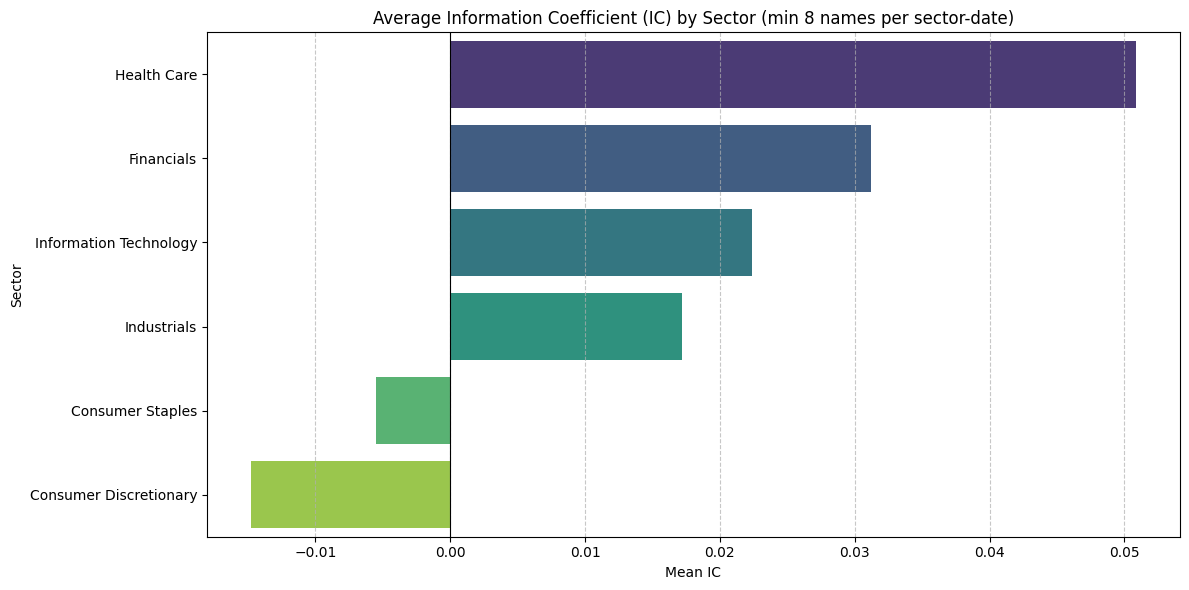

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

try:
    import seaborn as sns
    sns.barplot(x="IC_mean", y="sector", data=ic_by_sector,
                hue="sector", palette="viridis", legend=False, ax=ax)
except Exception:
    ax.barh(ic_by_sector["sector"], ic_by_sector["IC_mean"])
ax.set_title("Average Information Coefficient (IC) by Sector "
             f"(min {MIN_NAMES_PER_SECTOR_DATE} names per sector-date)")
ax.set_xlabel("Mean IC")
ax.set_ylabel("Sector")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


---

## Phase 10 — Feature importance (LightGBM, gain-based)

Feature importance from the final LightGBM model gives an interpretable check: the features the model weights most heavily should be plausible drivers of short-horizon equity returns. We report gain-based importance averaged across walk-forward windows.


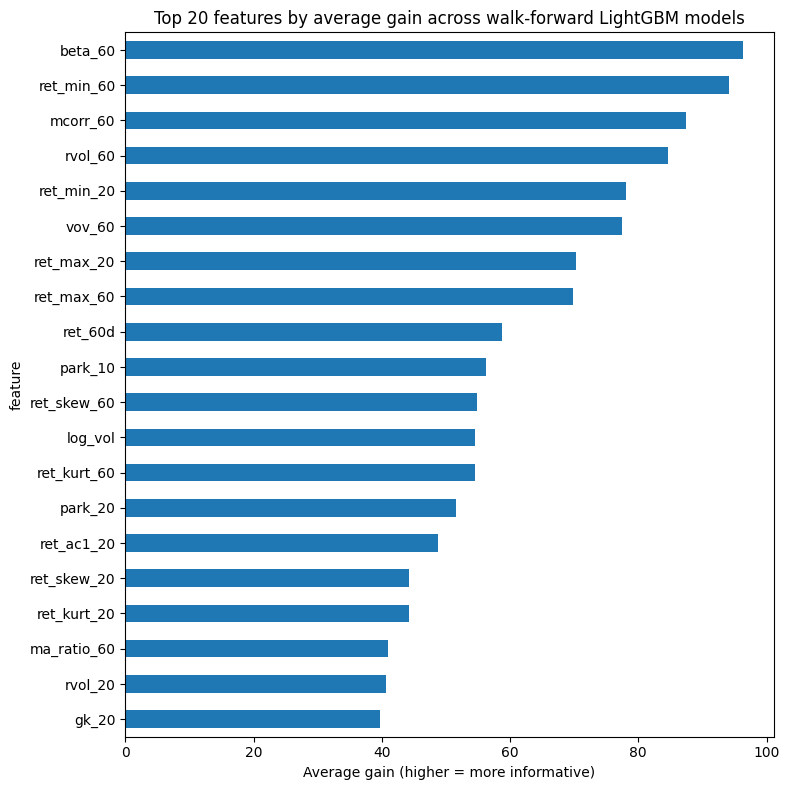


Top 20 features by average gain:
feature
beta_60        96.28
ret_min_60     94.22
mcorr_60       87.49
rvol_60        84.70
ret_min_20     78.12
vov_60         77.52
ret_max_20     70.30
ret_max_60     69.84
ret_60d        58.73
park_10        56.31
ret_skew_60    54.78
log_vol        54.55
ret_kurt_60    54.46
park_20        51.57
ret_ac1_20     48.82
ret_skew_20    44.29
ret_kurt_20    44.17
ma_ratio_60    40.99
rvol_20        40.68
gk_20          39.69


In [37]:
# Aggregate gain-based importance across all walk-forward LightGBM models
importance_frames = []
for i, m in enumerate(lgb_models):
    imp = pd.DataFrame({
        "feature": FEATURE_COLS,
        "gain": m.feature_importance(importance_type="gain"),
    })
    imp["window"] = i
    importance_frames.append(imp)

IMP = pd.concat(importance_frames, ignore_index=True)
avg_imp = IMP.groupby("feature")["gain"].mean().sort_values(ascending=False)

top_k = 20
fig, ax = plt.subplots(figsize=(8, 8))
avg_imp.head(top_k)[::-1].plot(kind="barh", ax=ax)
ax.set_title(f"Top {top_k} features by average gain across walk-forward LightGBM models")
ax.set_xlabel("Average gain (higher = more informative)")
plt.tight_layout(); plt.show()

print("\nTop 20 features by average gain:")
print(avg_imp.head(20).round(2).to_string())


### Top 10 Feature Importances (Formatted Table)



In [38]:
print(avg_imp.head(10).round(2).to_markdown())

| feature    |   gain |
|:-----------|-------:|
| beta_60    |  96.28 |
| ret_min_60 |  94.22 |
| mcorr_60   |  87.49 |
| rvol_60    |  84.7  |
| ret_min_20 |  78.12 |
| vov_60     |  77.52 |
| ret_max_20 |  70.3  |
| ret_max_60 |  69.84 |
| ret_60d    |  58.73 |
| park_10    |  56.31 |


### Correlation Matrix of Top 10 Features

Understanding the correlation between the top features can reveal potential multicollinearity issues or dependencies that might influence model interpretability or stability. A heatmap provides a clear visual representation of these relationships.

In [39]:
top_10_features = avg_imp.head(10).index.tolist()

# Filter the DATASET to include only the top 10 features and drop rows with NaN values
# This step is crucial because correlation calculation requires complete data.
correlation_data = DATASET[top_10_features].dropna()

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

print("Correlation matrix for the top 10 features:")
display(correlation_matrix.round(2))

Correlation matrix for the top 10 features:


,beta_60,ret_min_60,mcorr_60,rvol_60,ret_min_20,vov_60,ret_max_20,ret_max_60,ret_60d,park_10
beta_60,1.00,-0.42,0.67,0.53,-0.32,0.29,0.34,0.43,0.07,0.34
ret_min_60,-0.42,1.00,-0.33,-0.84,0.65,-0.74,-0.48,-0.53,0.28,-0.58
mcorr_60,0.67,-0.33,1.00,0.41,-0.24,0.29,0.21,0.26,-0.10,0.24
rvol_60,0.53,-0.84,0.41,1.00,-0.61,0.79,0.67,0.82,-0.07,0.69
ret_min_20,-0.32,0.65,-0.24,-0.61,1.00,-0.48,-0.50,-0.39,0.27,-0.73
vov_60,0.29,-0.74,0.29,0.79,-0.48,1.00,0.52,0.71,-0.07,0.50
ret_max_20,0.34,-0.48,0.21,0.67,-0.50,0.52,1.00,0.69,0.04,0.68
ret_max_60,0.43,-0.53,0.26,0.82,-0.39,0.71,0.69,1.00,0.20,0.53
ret_60d,0.07,0.28,-0.10,-0.07,0.27,-0.07,0.04,0.20,1.00,-0.16
park_10,0.34,-0.58,0.24,0.69,-0.73,0.50,0.68,0.53,-0.16,1.00


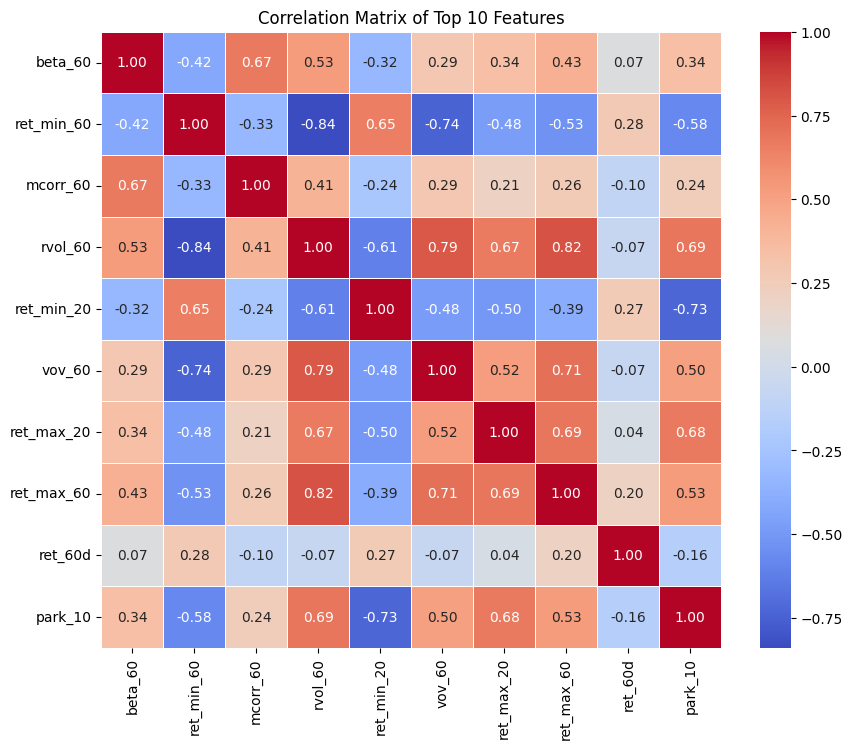

In [40]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Top 10 Features')
plt.show()

---

## Phase 11 — Caveats, limitations, and next steps

### Caveats and known limitations

1. **Survivorship bias.** The universe is fixed across the full period using a current-constituent-like list. A production pipeline would use a time-varying index-constituent database and include delisted names. Any alpha shown here may be inflated by the exclusion of names that underperformed to delisting.

2. **Transaction costs and market impact are not modeled.** The decile long-short backtest assumes frictionless execution at close prices. Realistic costs for a US large-cap L-S portfolio with the shown turnover would reduce Sharpe by a non-trivial amount. Turnover is reported explicitly so a reader can apply their own cost assumptions.

3. **Short-sale feasibility is not checked.** Some names in the short sleeve may have borrow constraints; we ignore this.

4. **Thematic overlay is deliberately simple.** Sector tilts are applied uniformly within a sector; a richer implementation would use sub-industry or thematic-basket mappings and size the tilts from confidence-weighted survey evidence.

5. **Data license.** Yahoo Finance data is used under Yahoo's terms of service for educational and research use. Redistribution or commercial use of the downloaded data is subject to those terms.

6. **No forward-looking fundamental data.** Purely market-microstructure features. A real equity research pipeline would add analyst estimate revisions, earnings surprise, fundamental ratios, and alternative data; the architecture here supports those additions without modification.

7. **Walk-forward windows are relatively few.** Statistical significance of Sharpe differences between models on ~6 windows is weak. Treat the comparison as directional.

### Reasonable next steps

- Swap the fixed universe for a point-in-time constituent list (e.g., S&P 500 or Russell 1000).
- Add fundamental features from SEC EDGAR filings (10-K/10-Q), which are public-domain.
- Replace the simple decile L-S with a constrained portfolio optimizer (turnover, leverage, single-name cap) — see the Horizon appendix of Notebook 2 for a GPU-accelerated version.
- Add execution cost modeling (basis-point cost per turnover).
- Explore alternative ML models from the Qlib model zoo (TRA, HIST, DoubleEnsemble) using the same feature backbone.
- Extend the thematic overlay to confidence-weighted tilts with decay.


---

## Phase 12 — References and notices

### References (academic and methodological)

- Microsoft Research (2020). *Qlib: An AI-oriented Quantitative Investment Platform.* arXiv:2009.11189.
- Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* NeurIPS.
- Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory.* Neural Computation, 9(8).
- Grinold, R. & Kahn, R. (1999). *Active Portfolio Management*, 2nd ed.
- Rockafellar, R. T. & Uryasev, S. (2000). *Optimization of Conditional Value-at-Risk.* Journal of Risk, 2, 21-42.

### Macro-research theme sources (public, cited for nominative reference only)

- HSBC Global Research. *Energy storage – The great enabler.* Published 2026-03-09. Accessed via `business.hsbc.com/en-gb/insights/energy-storage-the-great-enabler`.
- HSBC Global Research. *Will Europe join the AI party?* Published 2026-02-13.
- HSBC Global Research. *HSBC Emerging Markets Sentiment Survey – High conviction, higher caution.* Published 2026-03-25.
- HSBC Global Research. *Sustainability in 2026: Net zero navigator.* Published 2026-02-11.
- HSBC Global Research. *HSBC Global Trade Pulse Survey.* Published 2026-01-12.

### Software notices (NOTICES)

| Package | Version constraint | License |
| --- | --- | --- |
| numpy      | >=1.26,<2.2  | BSD-3-Clause |
| pandas     | >=2.1,<2.3   | BSD-3-Clause |
| scipy      | >=1.11       | BSD-3-Clause |
| scikit-learn | >=1.4     | BSD-3-Clause |
| lightgbm   | >=4.3        | MIT |
| yfinance   | >=0.2.40     | Apache-2.0 (Yahoo Finance data ToS applies to downloaded data) |
| matplotlib | >=3.7        | PSF-based (matplotlib license) |
| torch      | (Colab-provided) | BSD-style (PyTorch modified BSD-3) |
| tqdm       | >=4.66       | MIT / MPL-2.0 |

### Legal disclaimer (reiterated)

This notebook is an **independent educational research artifact**. It is not affiliated with, endorsed by, or sponsored by HSBC Holdings plc, HSBC Global Research, or any member of the HSBC Group, nor by any of the other research providers referenced. References to publicly-released HSBC Global Research publications are made for **academic commentary under nominative fair use**. No proprietary data, non-public research, or trademarked visual elements are reproduced. All trademarks are the property of their respective owners.

Nothing in this notebook constitutes investment advice. All returns shown are simulated backtests on historical data and are not indicative of future performance.

---

*End of Notebook 1.*
